Celem projektu jest zbudowanie modelu klasyfikacji binarnej opartego na Regresji Logistycznej, który na podstawie parametrów medycznych (np. wiek, poziom cholesterolu, typ bólu klatki piersiowej) przewidzi obecność choroby serca u pacjenta.

Regresja logistyczna to model statystyczny, który zamiast przewidywać bezpośrednio wartość (jak regresja liniowa), oblicza prawdopodobieństwo przynależności do danej klasy. Wykorzystuje do tego funkcję sigmoidalną, która "ściska" wynik dowolnego równania liniowego do przedziału od 0 do 1.


In [31]:
import pandas as pd


columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv('processed.cleveland.data', sep=',', names=columns)


df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Import oraz analiza występujacych danych.
    

In [32]:

df.loc[df['target'] > 0, 'target'] = 1


df['target'].value_counts()

target
0    164
1    139
Name: count, dtype: int64

Zamieniamy wszystkich chorych na 1, aby klasyfikowac tylko zdrowy/chory

In [33]:

(df == '?').sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Sprawdzamy ile jest pustych danych

In [7]:
import numpy as np

df = df.replace('?', np.nan)

df = df.dropna()

print(len(df))

297


Wstępna analiza wykazała obecność brakujących wartości oznaczonych jako '?'. Zdecydowałem się na ich usunięcie, ponieważ stanowiły one mniej niż 2% zbioru danych, co nie wpłynie negatywnie na proces uczenia, a zapewni czystość danych.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    object 
 12  thal      297 non-null    object 
 13  target    297 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 34.8+ KB


In [9]:

df['ca'] = df['ca'].astype(float)
df['thal'] = df['thal'].astype(float)


df.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Zmieniamy typ danych w kolumnach aby można było na nich dokonywać obliczeń, pandas widząc "?" zaklasyfikował całe kolumny jako typ "object"

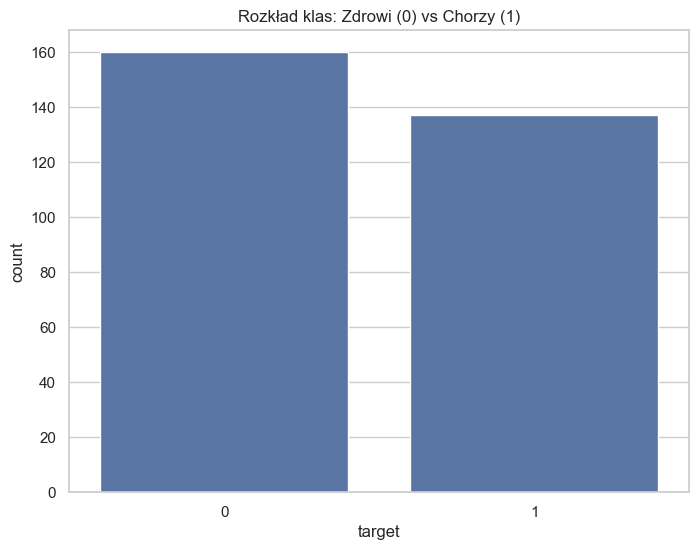

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df)
plt.title('Rozkład klas: Zdrowi (0) vs Chorzy (1)')
plt.show()

Rozkład chorzy i zdrowi


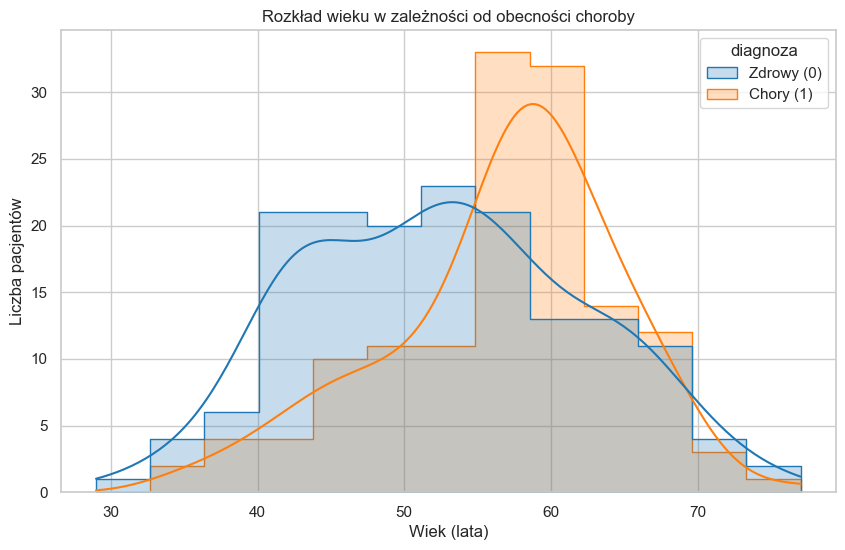

In [13]:

df_visual = df.copy()
df_visual['diagnoza'] = df_visual['target'].map({0: 'Zdrowy (0)', 1: 'Chory (1)'})

plt.figure(figsize=(10, 6))

sns.histplot(data=df_visual, x='age', hue='diagnoza', kde=True, element="step", 
             palette={'Zdrowy (0)': 'tab:blue', 'Chory (1)': 'tab:orange'})

plt.title('Rozkład wieku w zależności od obecności choroby')
plt.xlabel('Wiek (lata)')
plt.ylabel('Liczba pacjentów')
plt.show()

Z wykresu można odczytać, że wiek ma duży wpływ na bycie chorym. Szczyt przypada w wieku ok. 60 lat

In [ ]:

categorical_cols = ['cp', 'restecg', 'slope', 'thal']


df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


df.columns

Algorytmy uczenia maszynowego operują na liczbach, dlatego dane kategoryczne (np. typ bólu klatki cp) zostały poddane procesowi One-Hot Encoding (kodowanie 0-1). Zapobiega to błędnej interpretacji przez model, że np. typ bólu "4" jest matematycznie większy niż "1".



In [15]:

X = df.drop('target', axis=1)

y = df['target']


print(f"Kształt X: {X.shape}")
print(f"Kształt y: {y.shape}")

Kształt X: (297, 18)
Kształt y: (297,)


Dzielimy zbiór na cechy, X czyli wszystko oprócz targetu oraz y - target(czy chory)

In [16]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          297 non-null    float64
 1   sex          297 non-null    float64
 2   trestbps     297 non-null    float64
 3   chol         297 non-null    float64
 4   fbs          297 non-null    float64
 5   thalach      297 non-null    float64
 6   exang        297 non-null    float64
 7   oldpeak      297 non-null    float64
 8   ca           297 non-null    float64
 9   target       297 non-null    int64  
 10  cp_2.0       297 non-null    bool   
 11  cp_3.0       297 non-null    bool   
 12  cp_4.0       297 non-null    bool   
 13  restecg_1.0  297 non-null    bool   
 14  restecg_2.0  297 non-null    bool   
 15  slope_2.0    297 non-null    bool   
 16  slope_3.0    297 non-null    bool   
 17  thal_6.0     297 non-null    bool   
 18  thal_7.0     297 non-null    bool   
dtypes: bool(9), f

Sprawdzamy zbiór po przekształceniach, wszystko gra

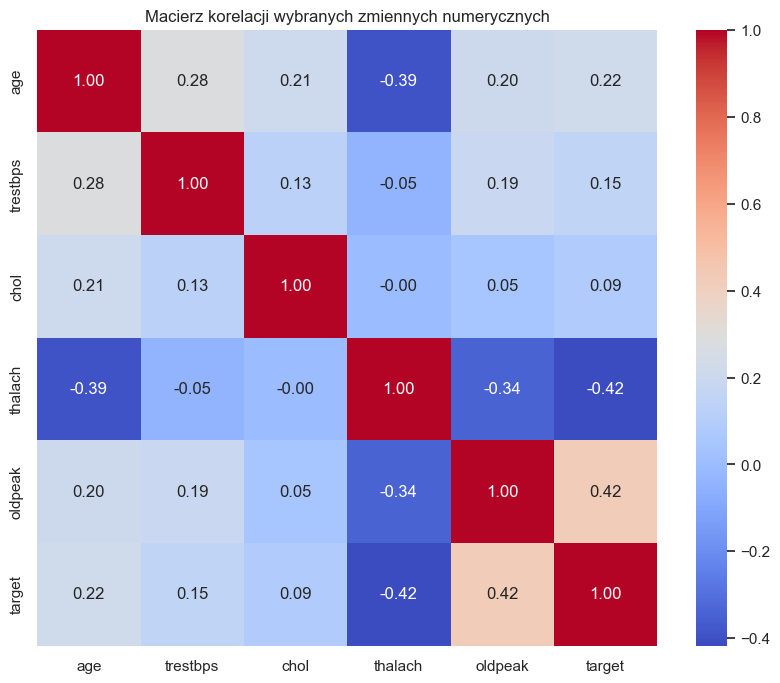

In [42]:

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(10, 8))

sns.heatmap(df[numerical_features + ['target']].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Macierz korelacji wybranych zmiennych numerycznych")
plt.show()

Zmienne numeryczne w naszym zbiorze nie są ze sobą zbyt mocno skorelowane (brak wartości bliskich 1 lub -1). Oznacza to, że nie mamy problemu ze współliniowością cech – każda z tych zmiennych wnosi do modelu unikalne informacje. Zauważamy też, że np. thalach (maksymalne tętno) ma umiarkowaną korelację z naszym celem predykcyjnym.

In [17]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Liczba pacjentów do nauki: {len(X_train)}")
print(f"Liczba pacjentów do testu: {len(X_test)}")

Liczba pacjentów do nauki: 237
Liczba pacjentów do testu: 60


Dzielimy dane: 80% do nauki 20% do testowania X to cechy, target to wynik

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

X_train_scaled[:3]

array([[-1.74167853, -1.52906121,  0.31928358, -0.54421318, -0.43698372,
         0.15179817, -0.73413966, -0.91504143, -0.72057669, -0.40925259,
         1.59289467, -0.98742088, -0.1132277 , -1.02998523,  1.03872391,
        -0.26906912, -0.24090603, -0.825137  ],
       [ 0.60111446, -1.52906121,  0.98598146, -0.1617713 , -0.43698372,
         0.97139911, -0.73413966, -0.12163356, -0.72057669, -0.40925259,
        -0.6277879 , -0.98742088, -0.1132277 , -1.02998523, -0.96271972,
        -0.26906912, -0.24090603, -0.825137  ],
       [ 1.60516859, -1.52906121,  0.4303999 , -0.1808934 , -0.43698372,
         0.10866128, -0.73413966,  0.67177432,  1.38777733, -0.40925259,
        -0.6277879 , -0.98742088, -0.1132277 , -1.02998523, -0.96271972,
        -0.26906912, -0.24090603, -0.825137  ]])

Dodatkowo zastosowano StandardScaler. Regresja logistyczna jest wrażliwa na skale zmiennych — bez skalowania model mógłby przypisać zbyt dużą wagę cechom o dużych wartościach (jak cholesterol), ignorując te o małych zakresach (jak wiek). Uczymy skaler na danych treningowych i je przeksztalcamy, a na danych testowych nie uczymy bo inaczej skaler "poznałby" średnią i odchylenie standardowe danych, które mają służyć jako ostateczny sprawdzian modelu.

In [19]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(C=1.0, solver='liblinear', random_state=42)


model.fit(X_train_scaled, y_train)


print(f"Dokładność na zbiorze treningowym: {model.score(X_train_scaled, y_train):.2f}")

Dokładność na zbiorze treningowym: 0.86


Tworzymy model, ustawiamy C- parametr regularyzacji(siła kary za skomplikowany model), nastepnie trenujemy model na przeskalowanych danych i sprawdzamy dokladnosc

Trenowanie modeli dla różnych wartości C...


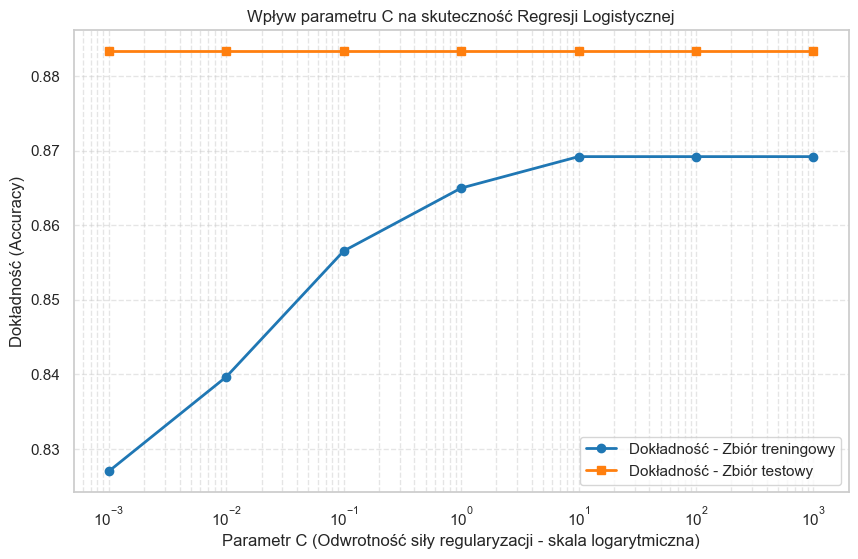

In [43]:
import matplotlib.pyplot as plt

train_accs = []
test_accs = []

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

print("Trenowanie modeli dla różnych wartości C...")

for c in C_values:
  
    temp_model = LogisticRegression(C=c, solver='liblinear', random_state=42)
    temp_model.fit(X_train_scaled, y_train)
    
  
    train_accs.append(temp_model.score(X_train_scaled, y_train))
    test_accs.append(temp_model.score(X_test_scaled, y_test))


plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accs, label='Dokładność - Zbiór treningowy', marker='o', color='tab:blue', linewidth=2)
plt.plot(C_values, test_accs, label='Dokładność - Zbiór testowy', marker='s', color='tab:orange', linewidth=2)

plt.xscale('log') 
plt.xlabel('Parametr C (Odwrotność siły regularyzacji - skala logarytmiczna)')
plt.ylabel('Dokładność (Accuracy)')
plt.title('Wpływ parametru C na skuteczność Regresji Logistycznej')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

 Wykres przedstawia wpływ parametru regularyzacji (C) na skuteczność modelu. Niebieska linia pokazuje, że przy wyższych wartościach C (słabsza regularyzacja) model coraz lepiej dopasowuje się do danych treningowych. Z kolei pomarańczowa linia (zbiór testowy) pozostaje płaska (ok. 88%). Świadczy to o tym, że dla tej konkretnej, niewielkiej próby testowej, zmiana regularyzacji nie wpływa na zdolność uogólniania modelu na nowe przypadki. Aby uniknąć potencjalnego przeuczenia, bezpiecznym i optymalnym wyborem pozostaje domyślna wartość $C=1$.

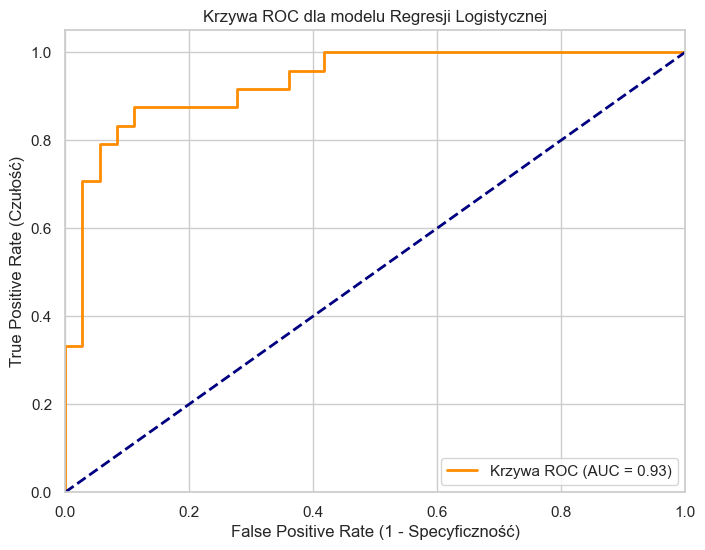

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score


y_probs = model.predict_proba(X_test_scaled)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Krzywa ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specyficzność)')
plt.ylabel('True Positive Rate (Czułość)')
plt.title('Krzywa ROC dla modelu Regresji Logistycznej')
plt.legend(loc="lower right")
plt.show()

Krzywa ROC (Receiver Operating Characteristic) przedstawia zależność między czułością (zdolnością do wykrywania chorych) a współczynnikiem fałszywych alarmów.

Idealny model dąży do lewego górnego rogu wykresu (wysoka czułość przy niskim błędzie).

Wskaźnik AUC (Area Under the Curve) to pole pod tą krzywą. Przyjmuje on wartości od 0 do 1.

1.0: Model idealny. 

0.5: Model działający jak rzut monetą (losowy). 

W naszym przypadku wynik powyżej 0.9 oznacza bardzo dobrą zdolność predykcyjną modelu w kontekście medycznym. Już przy FPR=0.1 mamy TPR = ponad 0.8

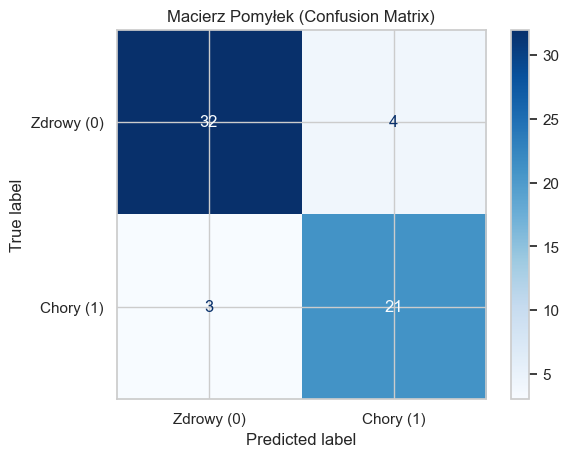

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Zdrowy (0)', 'Chory (1)'])
disp.plot(cmap='Blues')
plt.title('Macierz Pomyłek (Confusion Matrix)')
plt.show()

W diagnostyce medycznej bardzo ważna jest analiza rodzaju popełnianych błędów. Z powyższej macierzy wynika, że nasz model znakomicie radzi sobie z identyfikacją osób zdrowych (True Negatives) oraz chorych (True Positives). Wystąpiła jednak niewielka liczba tzw. Błędów II rodzaju (False Negatives - chory uznany za zdrowego). Ponieważ w medycynie jest to błąd krytyczny (może skutkować zaniechaniem leczenia), na tym etapie skuteczność algorytmu jest bardzo obiecująca, ale w realnych warunkach wymagałaby np. obniżenia progu decyzyjnego, aby jeszcze bardziej zminimalizować to ryzyko.

1. Analiza cech i korelacji (Wnioski z EDA):
Z eksploracyjnej analizy danych (EDA) wynika, że ryzyko choroby serca w naszym zbiorze zauważalnie rośnie z wiekiem (szczyt zachorowań w okolicach 60. roku życia). Dodatkowa weryfikacja za pomocą macierzy korelacji pozwoliła odkryć istotne zależności

   Istnieje zauważalna dodatnia korelacja (ok. 0.42) między parametrem oldpeak (obniżenie odcinka ST na EKG) a obecnością choroby.

    Zauważono ujemną korelację (-0.42) między maksymalnym tętnem (thalach) a celem predykcyjnym. Medycznie jest to uzasadnione – osłabione serce ma       trudności z osiągnięciem wysokiego tętna maksymalnego.
    Co bardzo ważne dla Regresji Logistycznej, nie zaobserwowaliśmy zjawiska współliniowości (brak silnych korelacji >0.8 między samymi cechami).         Dzięki temu każda zmienna wnosi do modelu unikalne informacje, a algorytm może poprawnie przypisać im wagi.                                        

2. Wpływ hiperparametru C na jakość modelu:Eksperyment z różnymi wartościami parametru C (który w bibliotece sklearn określa odwrotność siły regularyzacji.) przyniósł ciekawe wnioski:Zbyt silna regularyzacja (np. $C=0.001$) powodowała lekkie niedopasowanie (underfitting) na zbiorze treningowym.Wykres pokazał, że wraz ze wzrostem $C$ (osłabianiem kary za wysokie wagi) skuteczność na zbiorze treningowym stale rosła (niebieska linia), co przy ekstremalnych wartościach ($C=1000$) prowadzi do "uczenia się na pamięć" (overfittingu).Wynik na zbiorze testowym (pomarańczowa linia) pozostał na stabilnym poziomie ok. 88%. Wynika to z faktu, że nasz zbiór testowy jest bardzo mały (zaledwie 60 próbek). Aby zachować optymalny balans pomiędzy zdolnością uogólniania a dokładnością, zdecydowałem się pozostać przy domyślnej wartości $C=1.0$.

3. Skuteczność modelu i ocena krzywej ROC:
Ostateczny model wykazał się dużą skutecznością. Prawdziwą siłę modelu ukazuje jednak krzywa ROC oraz wskaźnik AUC na poziomie 0.93. Taki wynik (zbliżony do 1.0) świadczy o tym, że nasz klasyfikator wybitnie dobrze radzi sobie z separacją klas – potrafi utrzymać bardzo wysoką czułość (True Positive Rate) przy jednoczesnym minimalizowaniu fałszywych alarmów (False Positive Rate).

4. Kontekst medyczny (Analiza Macierzy Pomyłek):
W medycynie ogólna "dokładność" (accuracy) to nie wszystko. Najważniejsza jest analiza rodzajów błędów widoczna w Macierzy Pomyłek.
Szczególnie niebezpieczny jest Błąd II rodzaju (False Negative), czyli sytuacja, w której system klasyfikuje chorego pacjenta jako zdrowego (co skutkuje brakiem leczenia). Nasz model popełnia zaledwie pojedyncze błędy tego typu na zbiorze testowym. W realnym wdrożeniu medycznym rozważyłbym dodatkowe obniżenie progu decyzyjnego (threshold) poniżej domyślnych 0.5, aby wychwycić absolutnie wszystkich potencjalnie chorych pacjentów, nawet kosztem zwiększenia liczby fałszywych alarmów (Błędów I rodzaju, które w tym wypadku oznaczałyby tylko niepotrzebne skierowanie zdrowego pacjenta na dodatkowe badania).